# 07 SHAP 리포트 - 모델 해석

## 목적
- 06에서 선택한 최종 모델(LGB-B)이 각 변수를 어떻게 활용해 부도 확률을 예측하는지 설명
- 전역(global) 중요도 + 개별(local) 사례 설명 + 세그먼트별 차이 확인

## 구성
1. 데이터/모델 로드 (06과 동일한 split 재현)
2. 전역 변수 중요도 (bar + beeswarm)
3. 주요 변수 dependence plot
4. rule_segment별 SHAP 기여도 비교
5. 개별 사례 3건 waterfall (TP / FN / FP)
6. 결과 저장

## 산출물
- `outputs/figures/07_shap_importance_bar.png`
- `outputs/figures/07_shap_summary_beeswarm.png`
- `outputs/figures/07_shap_dependence_top4.png`
- `outputs/figures/07_shap_by_segment.png`
- `outputs/figures/07_waterfall_TP.png`, `07_waterfall_FN.png`, `07_waterfall_FP.png`
- `outputs/tables/07_shap_importance.csv`
- `outputs/tables/07_shap_importance_by_segment.csv`

## Step 0. 데이터 · 모델 로드 (06과 동일한 split 재현)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import lightgbm as lgb
import shap
import pickle
from sklearn.model_selection import train_test_split
from pathlib import Path

mpl.rc('font', family='Malgun Gothic')
mpl.rc('axes', unicode_minus=False)

OUT_TBL = Path("../outputs/tables")
OUT_FIG = Path("../outputs/figures")
OUT_MDL = Path("../outputs/models")

# 06과 동일한 전처리 + split 재현 (random_state=42로 동일한 test set 보장)
df = pd.read_parquet(OUT_TBL / "03_application_with_bureau.parquet")
seg = pd.read_csv(OUT_TBL / "05_segments.csv")
df = df.merge(seg[["SK_ID_CURR", "rule_segment"]], on="SK_ID_CURR", how="left")

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype("category")
df["rule_segment"] = df["rule_segment"].astype("category")

exclude = {"SK_ID_CURR", "TARGET", "rule_segment", "km_segment",
           "has_bureau", "bureau_count_filled"}
app_cols    = [c for c in df.columns if not c.startswith("bureau_") and c not in exclude]
bureau_cols = [c for c in df.columns if c.startswith("bureau_") or c in ("has_bureau", "bureau_count_filled")]

X_B = df[app_cols + bureau_cols + ["rule_segment"]]
y   = df["TARGET"]

X_B_tr, X_B_te, y_tr, y_te = train_test_split(X_B, y, test_size=0.2, random_state=42, stratify=y)

# 06에서 저장한 최종 모델 로드
with open(OUT_MDL / "lgbm_with_bureau.pkl", "rb") as f:
    model = pickle.load(f)

proba_te = model.predict_proba(X_B_te)[:, 1]
y_te_arr = y_te.values

print(f"Test set: {X_B_te.shape[0]}행 {X_B_te.shape[1]}개 변수")

Test set: 61503행 179개 변수


## Step 1. TreeExplainer로 SHAP 값 계산

In [3]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_B_te)

print(f"shap_values shape: {shap_values.values.shape}")

shap_values shape: (61503, 179)


## Step 2. 전역 변수 중요도

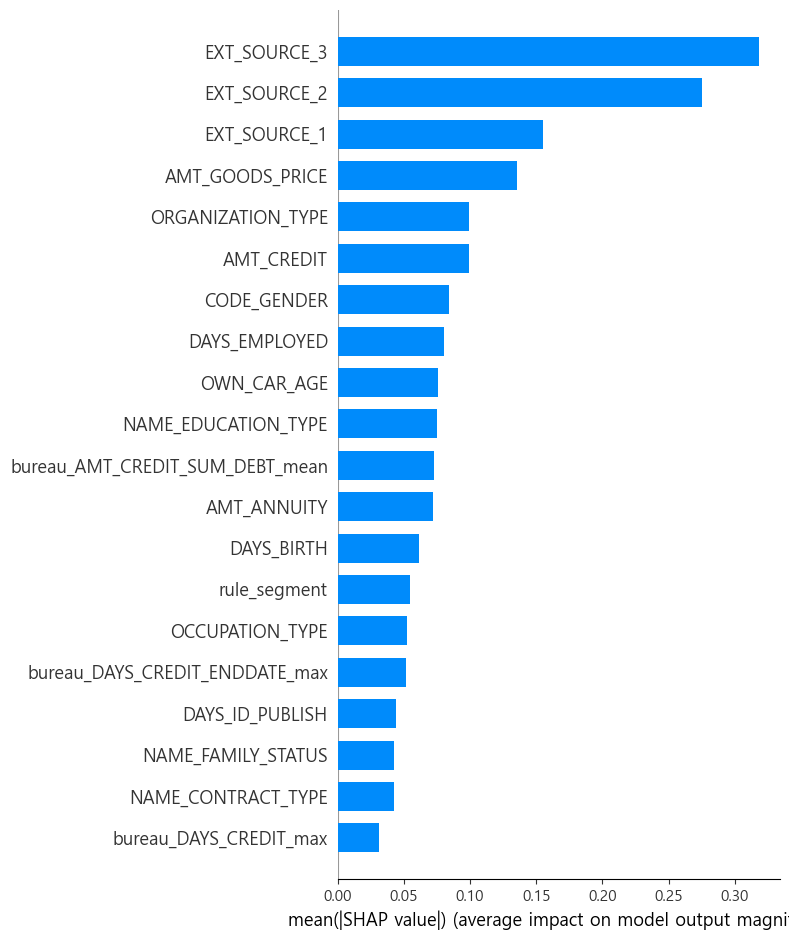

In [4]:
shap.summary_plot(shap_values, X_B_te, plot_type="bar", max_display=20, show=False)
plt.tight_layout()
plt.savefig(OUT_FIG / "07_shap_importance_bar.png", dpi=150, bbox_inches="tight")
plt.show()

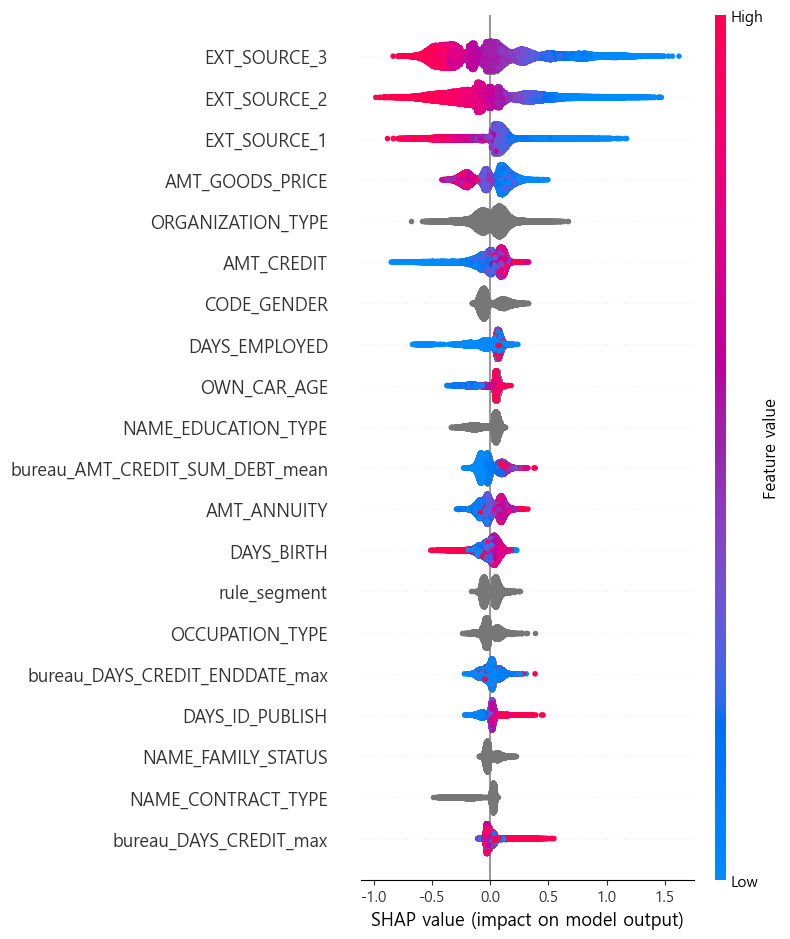

In [5]:
shap.summary_plot(shap_values, X_B_te, max_display=20, show=False)
plt.tight_layout()
plt.savefig(OUT_FIG / "07_shap_summary_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 3. 주요 변수 Dependence Plot

            feature  mean_abs_shap
       EXT_SOURCE_3       0.318249
       EXT_SOURCE_2       0.275036
       EXT_SOURCE_1       0.155443
    AMT_GOODS_PRICE       0.135175
  ORGANIZATION_TYPE       0.099313
         AMT_CREDIT       0.099169
        CODE_GENDER       0.084025
      DAYS_EMPLOYED       0.080360
        OWN_CAR_AGE       0.075996
NAME_EDUCATION_TYPE       0.074747


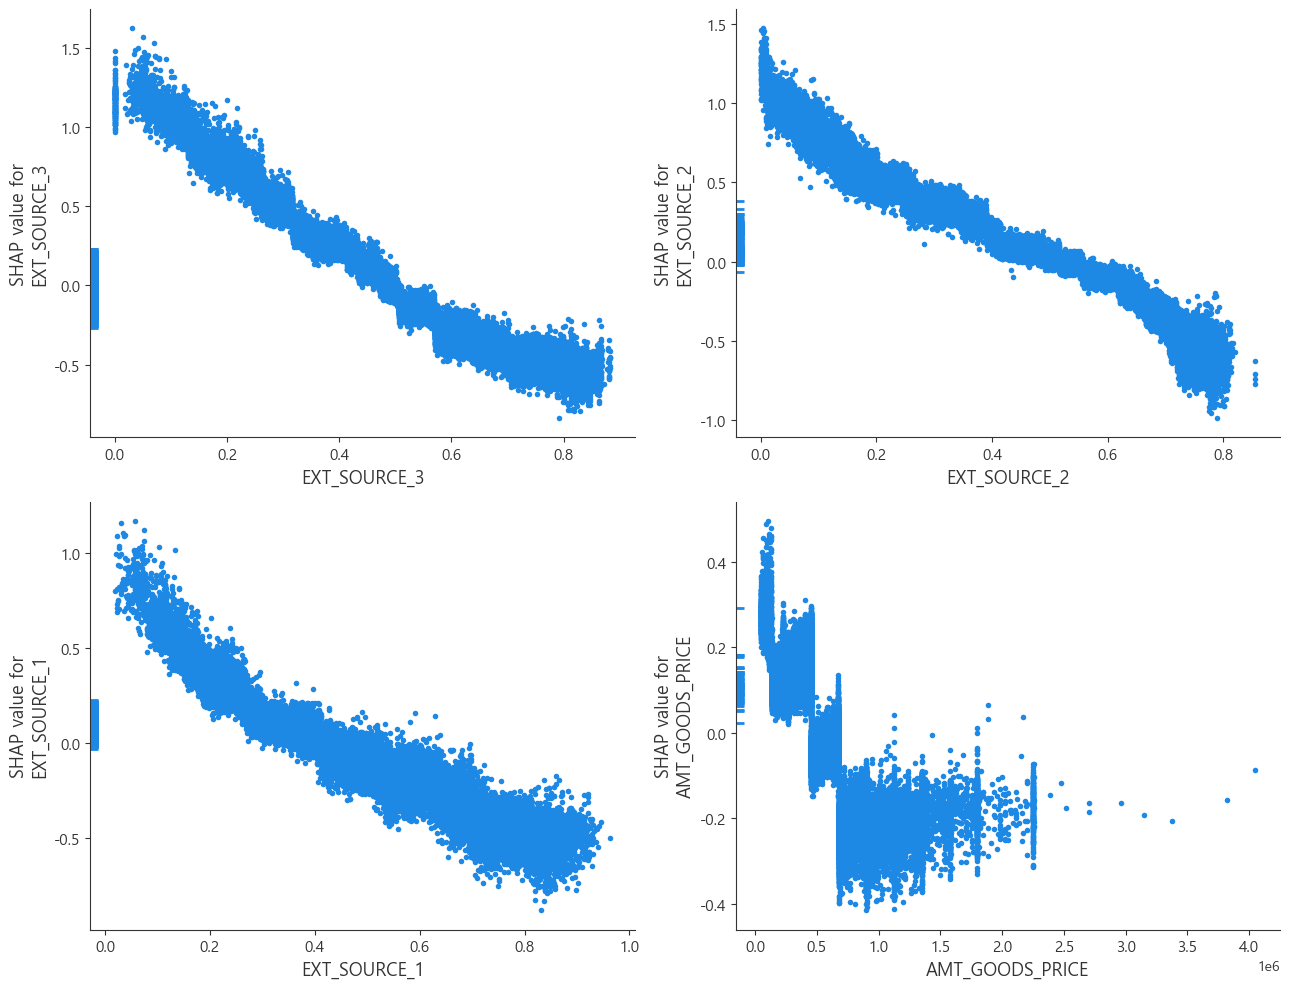

In [6]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
importance_df = (
    pd.DataFrame({"feature": X_B_te.columns, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
top_features = importance_df["feature"].head(4).tolist()
print(importance_df.head(10).to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, feat in zip(axes.ravel(), top_features):
    shap.dependence_plot(feat, shap_values.values, X_B_te, interaction_index=None, ax=ax, show=False)
plt.tight_layout()
plt.savefig(OUT_FIG / "07_shap_dependence_top4.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 4. rule_segment별 SHAP 기여도 비교

segment          S1: 고위험 (저신용+고DTI)  S2: 신생 차주 (저연령+단기고용)  S3: 과대출 (고DTI 단독)  \
feature                                                                        
AMT_GOODS_PRICE            0.182944              0.133388           0.185608   
EXT_SOURCE_1               0.144123              0.206863           0.134317   
EXT_SOURCE_2               0.576152              0.304196           0.196097   
EXT_SOURCE_3               0.315932              0.310539           0.295377   

segment          S4: 안정 차주 (고연령+양호)  S5: 우량 차주 (고신용)  S6: 보통 (분류 외)  
feature                                                              
AMT_GOODS_PRICE            0.121529         0.127878       0.141433  
EXT_SOURCE_1               0.121103         0.166870       0.160264  
EXT_SOURCE_2               0.233183         0.306990       0.269213  
EXT_SOURCE_3               0.307856         0.312557       0.328474  


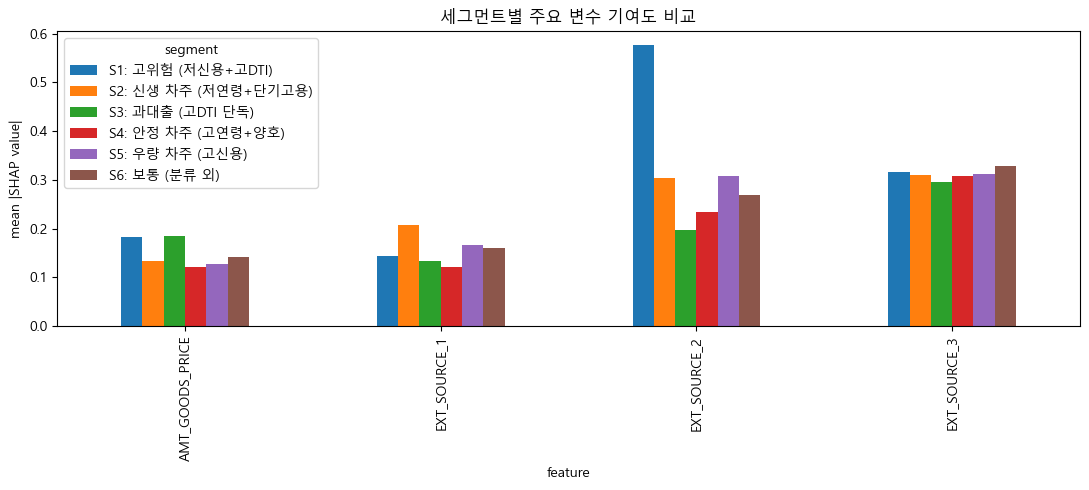

In [7]:
seg_col = df.loc[X_B_te.index, "rule_segment"].values

seg_importance = []
for s in pd.unique(seg_col):
    mask = seg_col == s
    seg_mean_abs = np.abs(shap_values.values[mask]).mean(axis=0)
    for feat, val in zip(X_B_te.columns, seg_mean_abs):
        seg_importance.append({"segment": s, "feature": feat, "mean_abs_shap": val})

seg_importance_df = pd.DataFrame(seg_importance)
top_feats_by_segment = (
    seg_importance_df[seg_importance_df["feature"].isin(top_features)]
    .pivot(index="feature", columns="segment", values="mean_abs_shap")
)
print(top_feats_by_segment)

top_feats_by_segment.plot(kind="bar", figsize=(11, 5))
plt.ylabel("mean |SHAP value|")
plt.title("세그먼트별 주요 변수 기여도 비교")
plt.tight_layout()
plt.savefig(OUT_FIG / "07_shap_by_segment.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 5. 개별 사례 설명 (TP / FN / FP)

TP (정확히 잡아낸 고위험) | SK_ID_CURR=156227 | 실제=1 | 예측확률=0.907


C:\Users\T\AppData\Roaming\Python\Python310\site-packages\shap\plots\_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
C:\Users\T\AppData\Local\Temp\ipykernel_15124\231569578.py:14: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\T\AppData\Local\Temp\ipykernel_15124\231569578.py:15: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.savefig(OUT_FIG / f"07_waterfall_{title.split()[0]}.png", dpi=150, bbox_inches="tight")
C:\Users\T\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


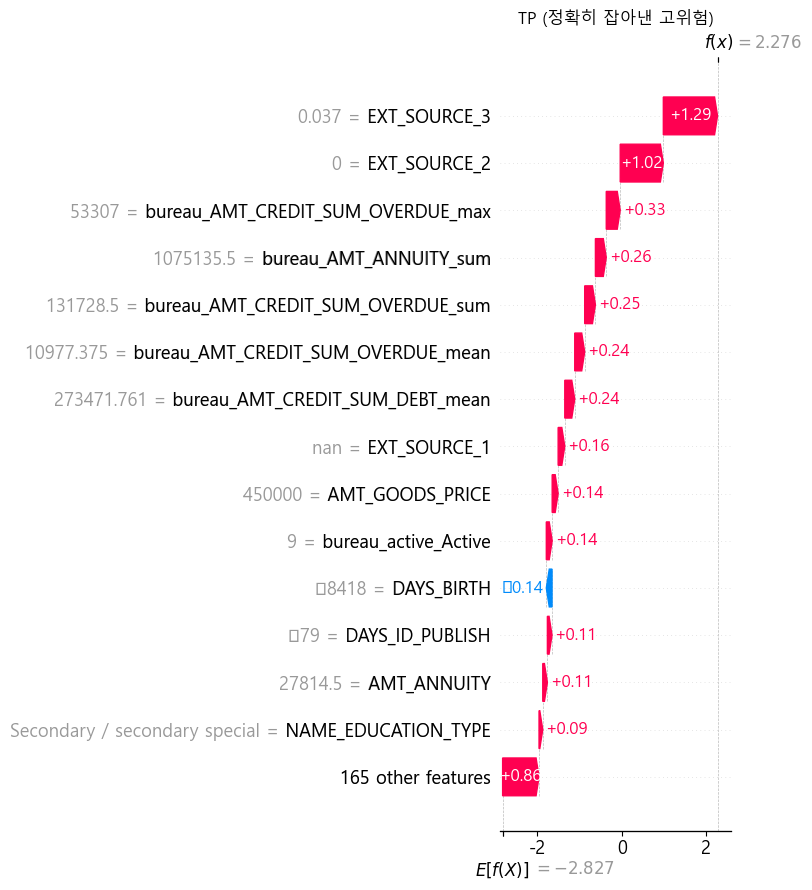

FN (놓친 실제 부도) | SK_ID_CURR=173242 | 실제=1 | 예측확률=0.007


C:\Users\T\AppData\Roaming\Python\Python310\site-packages\shap\plots\_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
C:\Users\T\AppData\Local\Temp\ipykernel_15124\231569578.py:15: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.savefig(OUT_FIG / f"07_waterfall_{title.split()[0]}.png", dpi=150, bbox_inches="tight")
C:\Users\T\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


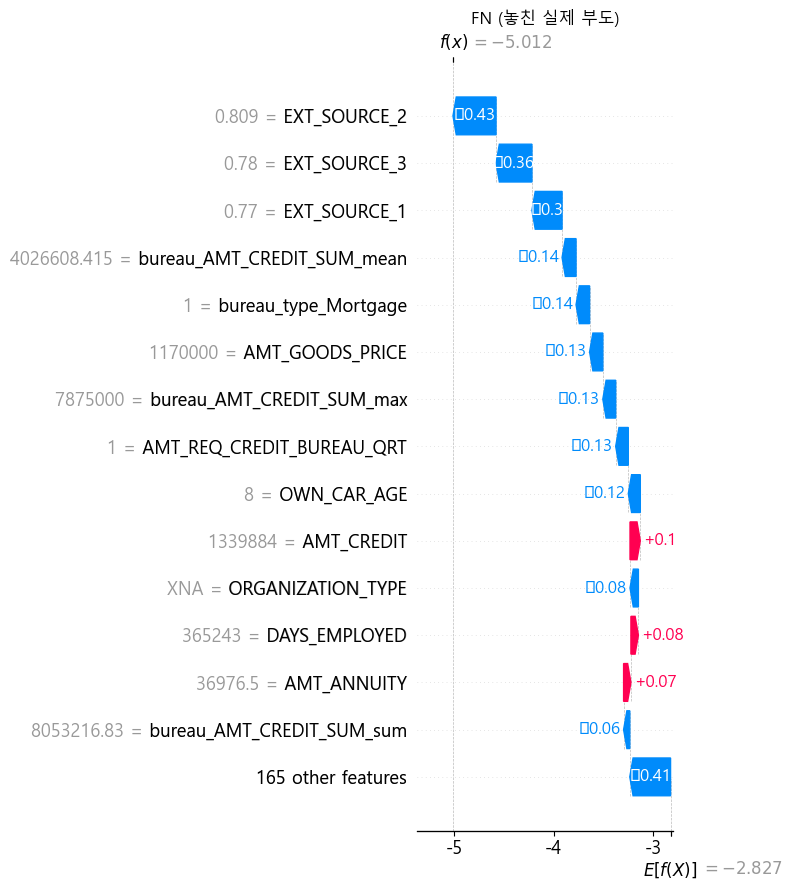

FP (오탐 - 안전한데 고위험으로 예측) | SK_ID_CURR=310035 | 실제=0 | 예측확률=0.711


C:\Users\T\AppData\Roaming\Python\Python310\site-packages\shap\plots\_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
C:\Users\T\AppData\Local\Temp\ipykernel_15124\231569578.py:14: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\T\AppData\Local\Temp\ipykernel_15124\231569578.py:15: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.savefig(OUT_FIG / f"07_waterfall_{title.split()[0]}.png", dpi=150, bbox_inches="tight")
C:\Users\T\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


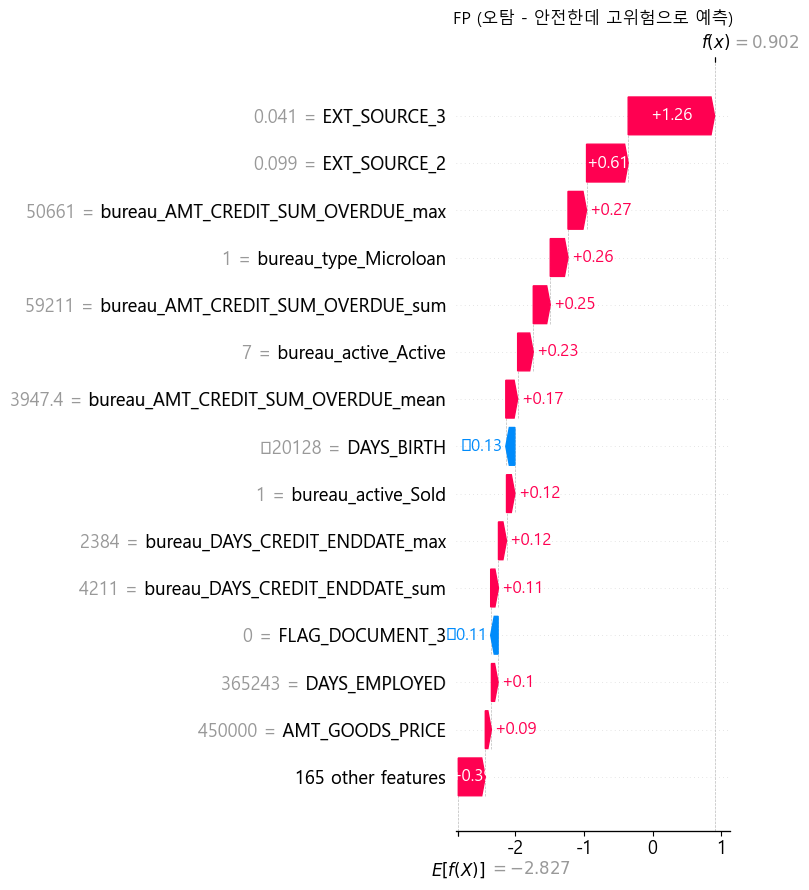

In [8]:
idx_tp = np.where(y_te_arr == 1)[0][np.argmax(proba_te[y_te_arr == 1])]
idx_fn = np.where(y_te_arr == 1)[0][np.argmin(proba_te[y_te_arr == 1])]
idx_fp = np.where(y_te_arr == 0)[0][np.argmax(proba_te[y_te_arr == 0])]

cases = [("TP (정확히 잡아낸 고위험)", idx_tp),
         ("FN (놓친 실제 부도)", idx_fn),
         ("FP (오탐 - 안전한데 고위험으로 예측)", idx_fp)]

for title, idx in cases:
    sk_id = df.loc[X_B_te.index[idx], "SK_ID_CURR"]
    print(f"{title} | SK_ID_CURR={sk_id} | 실제={y_te_arr[idx]} | 예측확률={proba_te[idx]:.3f}")
    shap.plots.waterfall(shap_values[idx], max_display=15, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(OUT_FIG / f"07_waterfall_{title.split()[0]}.png", dpi=150, bbox_inches="tight")
    plt.show()

## Step 6. 결과 저장

In [9]:
importance_df.to_csv(OUT_TBL / "07_shap_importance.csv", index=False)
seg_importance_df.to_csv(OUT_TBL / "07_shap_importance_by_segment.csv", index=False)
print("저장 완료: 07_shap_importance.csv, 07_shap_importance_by_segment.csv")

저장 완료: 07_shap_importance.csv, 07_shap_importance_by_segment.csv


## 결론

### 주요 변수 (전역)
- 압도적 Top 3: **EXT_SOURCE_3(0.318) > EXT_SOURCE_2(0.275) > EXT_SOURCE_1(0.155)** - 외부 신용점수 3종이 모델 판단의 절대적인 축.
- 그다음 그룹은 **AMT_GOODS_PRICE(0.135), ORGANIZATION_TYPE(0.099), AMT_CREDIT(0.099)** 등 한 단 낮은 중요도.
- bureau 계열 변수 중에서는 **bureau_AMT_CREDIT_SUM_DEBT_mean(0.073)**이 가장 상위 - 03번에서 조인한 신용정보국 데이터가 실제로 모델에 추가 신호를 제공하고 있음을 확인.
- ORGANIZATION_TYPE·CODE_GENDER·NAME_EDUCATION_TYPE은 범주형이라 beeswarm에서 회색으로 표시되지만 중요도 상위권 - 특정 카테고리가 강한 신호로 작용.

### Dependence Plot에서 발견한 패턴
- EXT_SOURCE_1/2/3 세 변수 모두 **점수가 높을수록 SHAP이 선형적으로 하락**하는 깔끔한 음의 단조 관계 - "외부 신용점수가 높으면 안전하다"를 모델이 그대로 학습.
- **AMT_GOODS_PRICE는 반대 방향의 특이 패턴**: 구매금액이 낮은 구간(~50만 이하)에서 SHAP이 +0.2~+0.5로 위험 쪽에 넓게 분포하다가, 구매금액이 커질수록(70만 이상) SHAP이 -0.2~-0.4로 떨어짐. 고가 구매일수록 오히려 모델이 안전하다고 판단 - 고가 상품 대출 심사가 더 엄격하게 걸러졌을 가능성.

### 세그먼트별 차이
- EXT_SOURCE_3은 전 세그먼트에서 0.29~0.33으로 고르게 중요 - 모델의 "기본 축" 역할.
- **EXT_SOURCE_2는 S1(고위험군)에서만 0.576으로 다른 세그먼트(0.2~0.3대) 대비 약 2배** - 룰로 이미 고위험 판정된 그룹 내부에서 모델이 세부 순위를 매길 때 EXT_SOURCE_2에 크게 의존.
- EXT_SOURCE_1은 S2(신생 차주, 저연령+단기고용)에서 0.207로 상대적으로 높음 - 재직 이력이 짧아 판단 근거가 부족한 대상일수록 외부 신용점수가 대체 신호로 쓰임.
- AMT_GOODS_PRICE는 S1(고위험)·S3(과대출)에서 0.18대로 높고 S4(안정차주)에서 0.122로 가장 낮음 - DTI가 높은 세그먼트일수록 구매금액 규모가 추가 판별 신호로 작동.

### 개별 사례 (TP/FN/FP) 해석
- **TP** (SK_ID_CURR=156227, 실제=1, 예측확률=0.907): EXT_SOURCE_3=0.037(+1.29), EXT_SOURCE_2=0(+1.02)로 극단적으로 낮은 외부점수가 위험 판단을 주도. 여기에 bureau 연체 변수(SUM_OVERDUE_max/sum/mean 등)가 각각 +0.24~+0.33 추가되며 확신 강화 → **낮은 외부점수 + 실제 연체이력이 겹쳐 정확히 잡아낸 케이스**.
- **FN** (SK_ID_CURR=173242, 실제=1, 예측확률=0.007): EXT_SOURCE_2=0.809, EXT_SOURCE_3=0.78, EXT_SOURCE_1=0.77로 세 점수 모두 높아 각각 -0.43/-0.36/-0.3로 강하게 안전 쪽으로 밀림. bureau 이력도 대체로 양호(모기지 보유 등) → **외부점수·기존 신용이력이 모두 좋아 보이지만 실제로는 부도난 케이스 = 모델의 구조적 사각지대**. 현재 피처셋에 없는 소득충격 등 외부 요인이 있었을 가능성.
- **FP** (SK_ID_CURR=310035, 실제=0, 예측확률=0.711): TP와 거의 동일한 패턴(낮은 EXT_SOURCE_3=0.041 +1.26, bureau 연체 변수 다수 +)이지만 실제로는 부도나지 않음 → **낮은 외부점수 + 연체이력이 항상 부도로 이어지진 않는다는 반례**. "회복력 있는 저신용자" 코호트가 존재함을 시사.

### 종합 인사이트
- 모델은 사실상 **EXT_SOURCE 3종(외부 신용평가기관 점수)에 절대적으로 의존**하며, bureau 연체/부채 변수가 개별 케이스의 확신도를 더하는 보조 역할을 함.
- **세그먼트 관점의 새로운 발견**: S1(고위험군) 내부의 실질적 판별력은 EXT_SOURCE_2가 담당 - 05번 비즈니스 룰이 "누가 위험군인지"를 나누면, 모델은 그 안에서 "얼마나 위험한지"를 EXT_SOURCE_2로 세분화하는 구조.
- FN 사례는 **외부 신용점수만으로는 포착되지 않는 부도가 실제로 존재**함을 보여줌 - 소득 변동성, 생애 이벤트 등 현재 피처에 없는 정보를 추가로 확보하면 모델 개선 여지가 있다는 한계이자 향후 과제.
